In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [2]:
df = pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")

print("Shape:", df.shape)
print(df.head())


Shape: (167, 10)
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None
       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.810000    0.

In [4]:
print(df.isnull().sum())


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [5]:
countries = df['country']

X = df.drop('country', axis=1)

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

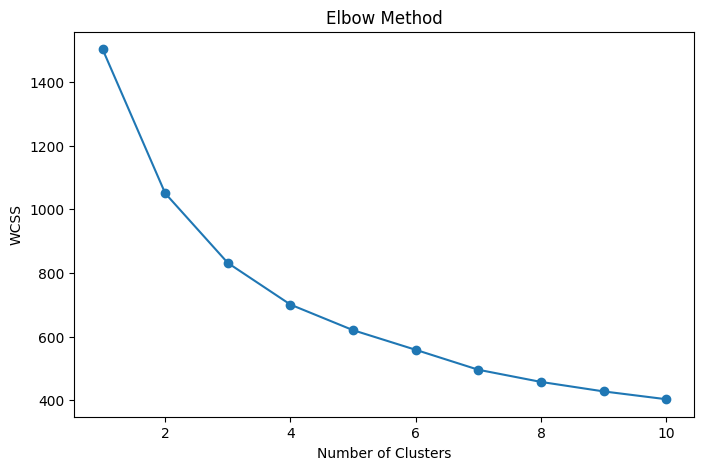

In [7]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [8]:
for k in range(2, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K = {k}, Silhouette Score = {score:.4f}")


K = 2, Silhouette Score = 0.2874
K = 3, Silhouette Score = 0.2833
K = 4, Silhouette Score = 0.2960
K = 5, Silhouette Score = 0.2993
K = 6, Silhouette Score = 0.2287
K = 7, Silhouette Score = 0.2477


In [9]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())


               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  Cluster  
0       9.44        56.2       5.82    553        1  
1       4.49        76.3       1.65   4090        2  
2      16.10        76.5       2.89   4460        2  
3      22.40        60.1       6.16   3530        1  
4       1.44        76.8       2.13  12200        2  


In [10]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

print("\nCluster Summary\n")
print(cluster_summary)


Cluster Summary

         child_mort    exports    health    imports        income  inflation  \
Cluster                                                                        
0          5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
1         92.961702  29.151277  6.388511  42.323404   3942.404255  12.019681   
2         21.927381  40.243917  6.200952  47.473404  12305.595238   7.600905   

         life_expec  total_fer          gdpp  
Cluster                                       
0         80.127778   1.752778  42494.444444  
1         59.187234   5.008085   1922.382979  
2         72.814286   2.307500   6486.452381  


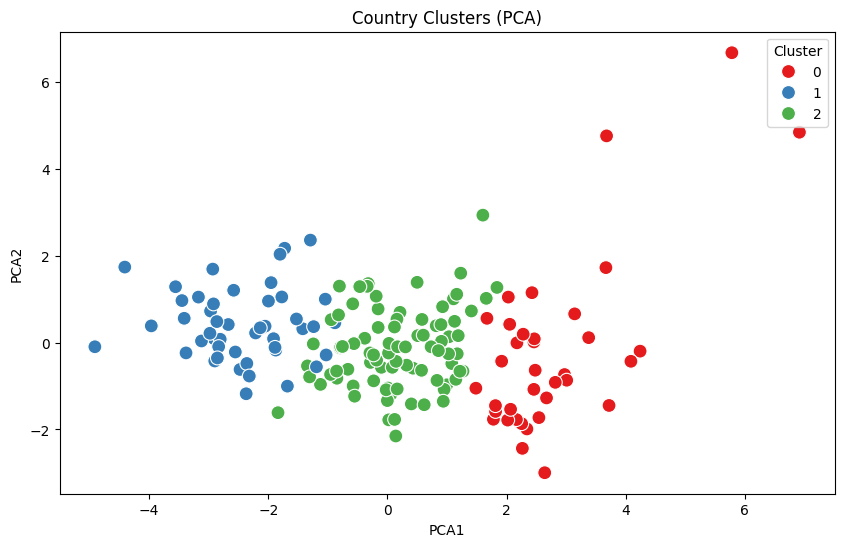

In [11]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

df['PCA1'] = pca_data[:,0]
df['PCA2'] = pca_data[:,1]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("Country Clusters (PCA)")
plt.show()

In [12]:
print("\nCluster Means:\n")
print(cluster_summary[['income','gdpp','child_mort','life_expec']])

# Cluster having:
# lowest income
# lowest GDP
# highest child mortality

target_cluster = cluster_summary['income'].idxmin()

print("\nMost Needy Cluster:", target_cluster)

needy_countries = df[df['Cluster'] == target_cluster]

print("\nCountries Requiring Aid:\n")
print(needy_countries['country'].tolist())


Cluster Means:

               income          gdpp  child_mort  life_expec
Cluster                                                    
0        45672.222222  42494.444444    5.000000   80.127778
1         3942.404255   1922.382979   92.961702   59.187234
2        12305.595238   6486.452381   21.927381   72.814286

Most Needy Cluster: 1

Countries Requiring Aid:

['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda', 'Yemen', 'Zambia']


In [13]:
top15 = needy_countries.sort_values(
    by=['gdpp','income'],
    ascending=True
)

print("\nTop 15 Countries Requiring Immediate Aid:\n")

print(
    top15[['country','gdpp','income',
           'child_mort','life_expec']]
    .head(15)
)



Top 15 Countries Requiring Immediate Aid:

                      country  gdpp  income  child_mort  life_expec
26                    Burundi   231     764        93.6        57.7
88                    Liberia   327     700        89.3        60.8
37           Congo, Dem. Rep.   334     609       116.0        57.5
112                     Niger   348     814       123.0        58.8
132              Sierra Leone   399    1220       160.0        55.0
93                 Madagascar   413    1390        62.2        60.8
106                Mozambique   419     918       101.0        54.5
31   Central African Republic   446     888       149.0        47.5
94                     Malawi   459    1030        90.5        53.1
50                    Eritrea   482    1420        55.2        61.7
150                      Togo   488    1210        90.3        58.7
64              Guinea-Bissau   547    1390       114.0        55.6
0                 Afghanistan   553    1610        90.2        56.2
56  

In [14]:
df.to_csv(
    "Country_Cluster_Result.csv",
    index=False
)

print("\nResult saved as Country_Cluster_Result.csv")


Result saved as Country_Cluster_Result.csv
